# CSCI 3352 Biological Networks, Prof. Clauset
Submit here: https://canvas.colorado.edu/courses/101449

# Problem Set 2 : Network representations and statistics

***

**Name**: Dominic Galgano

***

This assignment is due on Canvas by **11:55pm on Friday, February 2**. Your solutions to non-programming questions should be done in Markdown directly below the associated question. Your solutions to computational questions should include any specified Python code and results as well as written commentary on your conclusions.  Remember that you are encouraged to discuss the problems with your classmates, but **you must write all code and solutions on your own** (see syllabus for detailed guidance). There are 100 points total, and 17 pts extra credit.

**NOTES**: 

- Unless a url is given for a data set, you will find the required data on the course Canvas.
- If you're not familiar with typesetting math directly in Markdown, you may do your work on paper first and then typeset it later. This [reference guide](https://math.meta.stackexchange.com/questions/5020/mathjax-basic-tutorial-and-quick-reference) provides helpful guidance for writing math in Markdown. 
- It is **unhelpful** to make your reader interpret numerical output from your code.  If a question asks you to compute some value from the data you should show your code output **AND** write a summary of the results in Markdown directly below your code.

***
* networkx [Documentation](https://networkx.github.io/documentation/stable/) and [Tutorial](https://networkx.github.io/documentation/stable/tutorial.html)
* igraph [Documentation](https://igraph.org/python/versions/latest/install.html) and [Tutorial](https://igraph.org/python/tutorial/0.9.8/tutorial.html)

In [1]:
import networkx as nx
import numpy as np
import matplotlib
import matplotlib.pylab as plt
%matplotlib inline

***
## Problem 1 : Counting motifs (55 pts total)

Motifs are small subgraphs, often of 3 or 4 nodes, and their relative abundance can provide evidence for or against different underlying network assembly processes. Analyzing this kind of information depends on being able to count the number of occurrences of target motifs in a given network. In this problem, we'll develop such a counting algorithm.

***
### Problem 1-A (30 pts)

In directed networks, the two most commonly studied motifs are
* feed-forward loop ("FFL")
* cycle (sometimes called a feedback loop, or "FBL")

For instance, below is a simple directed graph (a "digraph") that contains one of each: the FFL is among nodes $\{1,2,3\}$ and the FBL is among nodes $\{4,5,6\}$.

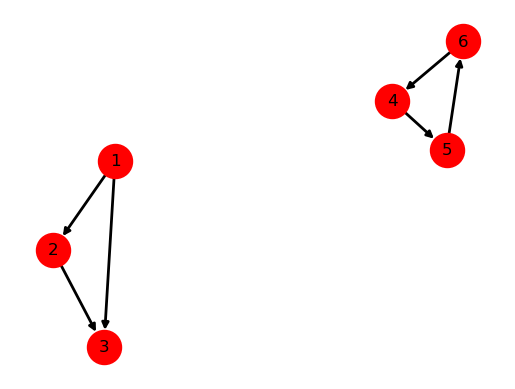

In [2]:
G = nx.DiGraph([(1,2), (2,3), (1,3), (4,5), (5,6), (6,4)])                            # make a directed network
nx.draw_networkx(G,arrows=True,with_labels=True,node_size=600,node_color='r',width=2) # draw it pretty
limits=plt.axis('off')                                                                # turn off axes
plt.show()                                                                            # show me the network!

* Write a function `count_FFBL_motifs()` that takes as input a directed graph `G` and a binary value `flag` and
  1. if `flag==1`, prints a statement of the form `FFL: (i,j),(j,k),(i,k)` or `FBL: (i,j),(j,k),(k,i)` for each FFL or non-unique FBL it finds, and
  * returns the counts the number of FFL motifs and the number of FBL motifs that `G` contains. <br/>
  
* Apply your function to the network `G` defined below, with `flag=1`, and report the FFL and FBL motif counts.
* Briefly explain how your algorithm for `count_FFBL_motifs()` works. (Note that the network is small enough that you can calculate the result by hand and use that information to debug your algorithm.)

Hint: Use a graph traversal approach to enumerate all paths of length two, e.g. $\sigma_{ijk} = \{(i\rightarrow j), (j \rightarrow k)\}$, where $i\not=k$, and for each, query the network for the existence of the third edge of the motif, either $(i,k)$ or $(k,i)$ depending on which motif is being counted. Within the DiGraph structure of `networkx`, the `neighbors` and `has_edge` functions will be useful.

*Warning*: remember that a single unique FBL motif can be counted 3 times, once for a 3-cycle starting at each of $i$, $j$, and $k$.

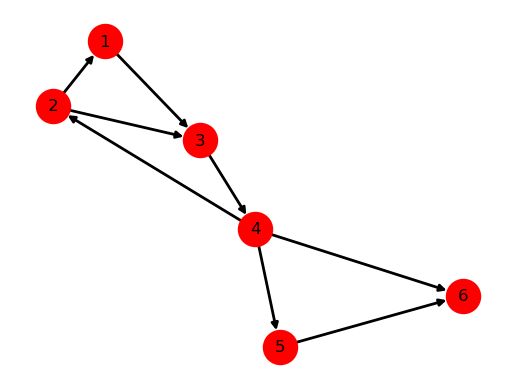

In [3]:
G = nx.DiGraph([(1,3),(2,1),(2,3),(3,4),(4,2),(4,5),(4,6),(5,6)])
nx.draw_networkx(G,arrows=True,with_labels=True,node_size=600,node_color='r',width=2) # draw it pretty
limits=plt.axis('off')                                                                # turn off axes
plt.show()                                                                            # show me the network!

In [37]:
def count_FFBL_motifs(G,flag):
    # input : a networkx digraph G and a binary-valued variabe flag
    # output: if flag=1, a print statement of the type {FFL,FBL} and its member edges for each found motif
    #         a list (FFL,FBL) of the counts of feed-forward and feed-back loops in G
    
    if(G.size() > 0):
        #Loops through every node to see if it has a connecting path to another node
        FFL_count = 0
        for source_node in G:
            for target_node in nx.all_neighbors(G, source_node):
                #Checks if there are multiple paths between the two neighboring nodes
                simple_paths = list(nx.all_simple_paths(G, source = source_node, target = target_node, cutoff=2))
                #If there are multiple paths between neighboring nodes then FFL exists
                if(len(simple_paths) > 1):
                    FFL_count = FFL_count + 1
                    
                    if(flag == 1):
                        #Displays the ffl
                        FFL = []
                        for ffl_display in map(nx.utils.pairwise, simple_paths):
                            for edge in ffl_display:
                                FFL.append(edge)
                        print("FFL:", FFL)
        
        #Using networkx finds all simple/unique feedback loops in the graph
        FBL_count = 0
        for cycle in nx.simple_cycles(G):
            FBL_count = FBL_count + 1
            
        if(flag == 1):
            for cycle_display in map(nx.utils.pairwise, nx.simple_cycles(G)):
                #Placed here to empty list on each loop
                FBL = []
                for edge in cycle_display:
                    FBL.append(edge)
                #Pulls out the first node from the first edge and the last node 
                #from last edge to make final connecting edge
                final_edge = FBL[len(FBL) - 1][1], FBL[0][0]
                FBL.append(final_edge)
                print("FBL:", FBL)
    
    return (FFL_count,FBL_count)

In [38]:
##### do not modify below here #####
counts = count_FFBL_motifs(G,1)

print(f'FFL count = {counts[0]}')
print(f'FBL count = {counts[1]}')

FFL: [(2, 1), (1, 3), (2, 3)]
FFL: [(4, 5), (5, 6), (4, 6)]
FBL: [(1, 3), (3, 4), (4, 2), (2, 1)]
FBL: [(2, 3), (3, 4), (4, 2)]
FFL count = 2
FBL count = 2


To find all the FFLs my algorithm loops through each node, designated as the source node, and compares it to every other node, the target, node to find all the simple paths between the source node and target node. Next my algorithm converts the nodes along this path into their respective edge pairs. Following this it checks if for lists of these edges pairs with a length of 2 as hinted in the instructions. When an edge list of length 2 is found, a check is made to see if there is a direct path between the source node and the target node. If there is then a feed-forward loop must be present.

To find all the FBLs my algorithm loops though all nodes and finds all unique simple cycles using the networkx simple_cycles() function. It then appends all the edges in the cycle to a list and pulls the first node of the first edge and last node of the last edge out of this list to create a final edge to append to the list. This was done to achieve proper formatting.

### Problem 1-B (15 pts)
Before applying your motif counting function from `Problem 1-A` to some real data, follow the standard 'good practice' when importing a new network data set by computing and examining its summary statistics, which provides context for interpreting the output from counting motifs.

For the `metabolism_afulgidus` directed network, compute and report
* the number of nodes $n$ and directed edges $m$
* the mean in-degree $\langle k_{\rm in} \rangle$ and mean out-degree $\langle k_{\rm out} \rangle$
* a CCDF plot showing the in- and out-degree distribution $\Pr(K \geq k_{\rm in})$ and $\Pr(K \geq k_{\rm out})$ together (use the provided `plot_2CCDF()` function).
* the smallest number of nodes that together account for just over 50% of the out-degree 'wealth' in the network

Comment briefly on
* the applicability of the formula $\langle k \rangle = 2m/n$
* why the values for $\langle k_{\rm in} \rangle$ and $\langle k_{\rm out} \rangle$ turn out the way they do, and on their relationship to $2m/n$.
* what, if anything, the shape of the in- and out-degree CCDFs indicate about the degree distributions of this network, and what that implies about metabolism.

(*2 pts extra credit*) Include a ridiculogram visualization of the network.

In [39]:
def plot_2CCDF(kins,kouts):
    # input : two lists of in- and out-degrees
    # output: a plot showing CCDFs of the in- and out-degree distributions Pr(K>=k) for k>=1
    
    kin_max  = max(kins)
    kout_max = max(kouts)

    # histograms
    icounts, ibins = np.histogram(kins, bins=[i for i in range(kin_max+2)], density=True)
    icumcounts = np.cumsum(icounts)
    icumcounts = np.insert(icumcounts,0,0)
    ocounts, obins = np.histogram(kouts, bins=[i for i in range(kout_max+2)], density=True)
    ocumcounts = np.cumsum(ocounts)
    ocumcounts = np.insert(ocumcounts,0,0)

    # plots
    fig = plt.figure()
    ax1 = fig.add_subplot(111) # put multiple 
    plt.loglog(obins[1:-1], 1-ocumcounts[1:-1], 'bo', alpha=0.5, label='out-degree')
    plt.loglog(ibins[1:-1], 1-icumcounts[1:-1], 'rs', alpha=0.5, label='in-degree')
    plt.title('CCDF, in- and out-degrees (loglog)')
    plt.xlabel('Degree, k')
    plt.ylabel('Pr(K>=k)')
    plt.legend(loc='upper right');
    plt.show()
    return

reading the network file : metabolism_afulgidus.gml

number of nodes, n  = 315
number of edges, m  = 5434

mean(k_in)  = 17.25
mean(k_out) = 17.25

smallest num for 50%  = 32 of 315 nodes


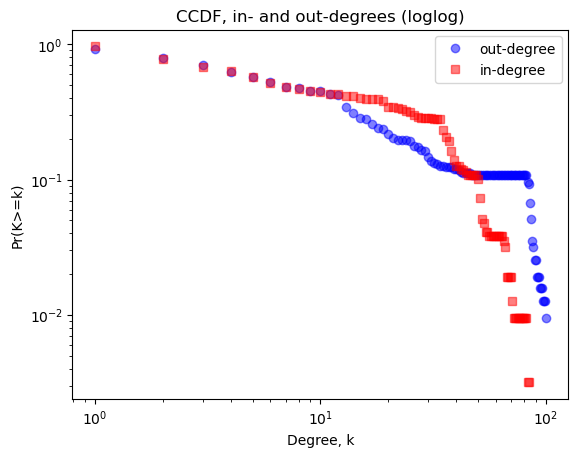

In [40]:
# this data set is from Gorochowski et al., Science Advances 4(3), eaap9751 (2018) 
# https://advances.sciencemag.org/content/4/3/eaap9751
fname = 'metabolism_afulgidus.gml'
print(f'reading the network file : {fname}\n')
##### do not modify above here #####


# Your code here
#Import the file into a networkx graph
meta_af = nx.read_gml(fname , label='id')
#Gets the number of nodes and stores them in n
n = meta_af.number_of_nodes()
#Gets the number of edges and stores them in m
m = meta_af.number_of_edges()

#Sums all in edges in the graph
kins = []
kouts = []
for node in meta_af:
    kins.append(meta_af.in_degree(node))
    kouts.append(meta_af.out_degree(node))
#Calculates average using (total in degrees / # of nodes)
kin_mean = np.mean(kins)
kout_mean = np.mean(kouts)

half_out_wealth = np.sum(kouts) / 2
kouts = np.sort(kouts)
#Tracks the sum of the out degree wealth of the nodes
wealth_sum = 0
#ind is min number of nodes needed to contain 50% of the edge wealth
i = len(kouts) - 1
while wealth_sum < half_out_wealth:
    wealth_sum = wealth_sum + kouts[i]
    i = i - 1

ind = n - i

##### do not modify below here #####
print(f'number of nodes, n  = {n}')
print(f'number of edges, m  = {m}')
print(f'\nmean(k_in)  = %5.2f' % kin_mean)
print(f'mean(k_out) = %5.2f' % kout_mean)
print(f'\nsmallest num for 50%  = {ind} of {n} nodes')
plot_2CCDF(kins,kouts)

* the applicability of the formula $\langle k \rangle = 2m/n$

The formula is still applicable to the directed graph because if we take $\langle k_{\rm in} \rangle + \langle k_{\rm out} \rangle = \frac{edge_{in}}{n} + \frac{edge_{out}}{n}$ to get $\frac{edge_{total}}{n}$ we have an equvialent formula to $2 * m / n$ which means the original $2 * m / n$ also gives the same <$k$> total mean of in and out  connectivity for the directed graph as it does the undirected graph 

* why the values for $\langle k_{\rm in} \rangle$ and $\langle k_{\rm out} \rangle$ turn out the way they do, and on their relationship to $2m/n$.

The reason that $\langle k_{\rm in} \rangle$ and $\langle k_{\rm out} \rangle$ turn out the way they do is because for every edge directed out of one node in the graph which will affect the value of $\langle k_{\rm out} \rangle$ there must be an equivalent edge directed back into another node(or even the same node) which will affect the value of $\langle k_{\rm in} \rangle$ in the same way. Therefore, as long as all edges are fully connected in the graph $\langle k_{\rm in} \rangle = \langle k_{\rm out} \rangle$ and they will be half of $\langle k_{\rm total} \rangle = 2m/n$

* what, if anything, the shape of the in- and out-degree CCDFs indicate about the degree distributions of this network, and what that implies about metabolism.

The CCDF distribution indicates the presence of "super highways" within the graph which contain a significant amount of the "edge wealth", nodes with relatively large numbers of edges. It appears the out-degree wealth has a slightly more extreme distribution(if that is possible). Overall, the CCDF implies the metabolism is distributed extremely unevenly 

### Problem 1-C (10 pts)
* Apply your motif counting function `count_FFBL_motifs()` from `Problem 1-A` to the `metabolism_afulgidus` directed network, with `flag=0`, to count its FFL and FBL motifs.
* Report the number of each that you find, and comment briefly on (1) their relative abundance, and (2) what you think this might mean for how 'information' might flow across this network.

In [ ]:
# Your code here
counts = count_FFBL_motifs(meta_af, 0)

##### do not modify below here #####
print(f'FFL count = {counts[0]}')
print(f'FBL count = {counts[1]}')

Your discussion here

***
***
## Problem 2 : Graph representations (12 pts total)

Consider the following networks.

Network 1:
![alt text](https://aaronclauset.github.io/courses/3352/network_represent_1.png "Network 1")

Network 2:
![alt text](https://aaronclauset.github.io/courses/3352/network_represent_2.png "Network 2")

***
### Problem 2-A (3 pts)

For Network 1, give the adjacency matrix representation. Let $(i\to j) \implies A_{ij}=1$.

| i,j | 1 | 2 | 3 | 4 | 5 |
| - | - | - | - | - | - |
| 1 | 0 | 0 | 1 | 1 | 0 |
| 2 | 1 | 0 | 0 | 0 | 0 |
| 3 | 0 | 1 | 0 | 0 | 1 |
| 4 | 0 | 0 | 0 | 0 | 1 |
| 5 | 1 | 0 | 0 | 1 | 0 |

or      $\begin{array}{cc} 0 & 0 & 1 & 1 & 0  \\ 1& 0& 0& 0& 0 \\ 0& 1& 0& 0& 1 \\ 0& 0& 0& 0& 1 \\ 1& 0& 0& 1& 0\end{array}$

***
### Problem 2-B (3 pts)

For Network 1, give the adjacency list representation.

Network 1 = [(1,2),(1,5),(2,3),(3,1),(4,1),(4,5),(5,3),(5,4)]

***
### Problem 2-C (6 pts)

For Network 2, give the adjacency matrix representation of both one-mode projections.

| i,j | 1A | 2A | 3A | 4A | 5A |
| - | - | - | - | - | - |
| 1B | 1 | 0 | 0 | 0 | 1 |
| 2B | 1 | 0 | 1 | 0 | 0 |
| 3B | 1 | 1 | 0 | 1 | 0 |
| 4B | 0 | 0 | 0 | 1 | 0 |
| 5B | 0 | 1 | 0 | 0 | 1 |
| 6B | 0 | 0 | 1 | 0 | 0 |

| j,i | 1B | 2B | 3B | 4B | 5B | 6B |
| - | - | - | - | - | - | - |
| 1A | 1 | 1 | 1 | 0 | 0 | 0 |
| 2A | 0 | 0 | 1 | 0 | 1 | 0 |
| 3A | 0 | 1 | 0 | 0 | 0 | 1 |
| 4A | 0 | 0 | 1 | 1 | 0 | 0 |
| 5A | 1 | 0 | 0 | 0 | 1 | 0 |

***
***

## Problem 3 : Calculations by hand (13 pts total)

For each of the following networks, calculate the requested information by hand.

Do not use software to do these calculations. Write up your answer in Markdown in the corresponding box below.

***
### Problem 3-A (6 pts)

* Enumerate and count the number of 2-cycle motifs <br/> write each in the form $(a\to b\to a)$
* Enumerate and count the number of FFL and unique FBL motifs <br/> for each FFL, note which node is "feeding forward" a signal
* Enumerate and count the number of _walks_ of length 3 <br/> write each in the form $(a\to b\to c \to d)$

Hint: A _walk_ and a _path_ are slightly different. In the former, nodes can be repeated, while in the latter, they cannot.

In [ ]:
G = nx.DiGraph([(1,3),(2,1),(2,3),(3,4),(4,2),(4,5),(4,6),(5,6)])                     # make a directed network
nx.draw_networkx(G,arrows=True,with_labels=True,node_size=600,node_color='r',width=2) # draw it pretty
limits=plt.axis('off')                                                                # turn off axes
plt.show()                                                                            # show me the network!

* Enumerate and count the number of 2-cycle motifs <br/> write each in the form $(a\to b\to a)$

There are $0$ two-cycle motifs in the graph since no two nodes have edges both have a shared incoming and outgoing edge with another node

* Enumerate and count the number of FFL and unique FBL motifs <br/> for each FFL, note which node is "feeding forward" a signal

FFLs:<br/>
$[(4) \to (5) \to (6)]$ where $(4 \to 6)$ feeds foward<br/>
$[(2) \to (1) \to (3)]$ where $(2 \to 3)$ feeds foward<br/>
Total FFLs: $2$<br/>

Unique FBLs:<br/>
$[(1) \to (3) \to (4) \to (2)]$<br/>
$[(2) \to (3) \to (4)]$<br/>
Total FBLs: $2$<br/>

* Enumerate and count the number of _walks_ of length 3 <br/> write each in the form $(a\to b\to c \to d)$

Walks with length 3:<br/>
1:$[(1) \to (3) \to (4) \to (2)]$<br/>
2:$[(1) \to (3) \to (4) \to (4)]$<br/>
3:$[(1) \to (3) \to (4) \to (6)]$<br/>
4:$[(2) \to (1) \to (3) \to (4)]$<br/>
5:$[(2) \to (3) \to (4) \to (2)]$<br/>
6:$[(2) \to (3) \to (4) \to (5)]$<br/>
7:$[(2) \to (3) \to (4) \to (6)]$<br/>
8:$[(3) \to (4) \to (5) \to (6)]$<br/>
9:$[(3) \to (4) \to (2) \to (1)]$<br/>
10:$[(3) \to (4) \to (2) \to (3)]$<br/>
11:$[(4) \to (2) \to (1) \to (3)]$<br/>
12:$[(4) \to (2) \to (3) \to (4)]$<br/>

Total Length 3 Walks: $12$<br/>

***
### Problem 3-B (7 pts)

Let $G$ be the [Petersen Graph](https://en.wikipedia.org/wiki/Petersen_graph), with $n=10$ nodes and $m=15$ edges. For $\ell\in\{2,3,4,5\}$, count the number of $\ell$-cycles in $G$. For convenience, label the outer nodes $(1,2,3,4,5)$ starting at 12 o'clock and running clockwise, and label the inner nodes $(6,7,8,9,10)$ in the same fashion.

Hint: a *cycle* is a path (no edges repeated) that begins and ends at the same node.

![Graph](Petersen.png)

$\ell$-cycles:<br/>
2: Since there is only one path of length two which returns back to the source node in this undirected simple graph and it uses the same edge twice, there are $0$ cycles of length $2$ in this graph<br/>

3: Due to the non-random design of this graph there also appears to be no paths of length $3$ which form a cycle that starts at and returns to the same node which does not include the same edge twice<br/>

4: Due to the non-random design of this graph there also appears to be no paths of length $4$ which form a cycle that starts at and returns to the same node which does not include the same edge twice<br/>

5: Due to the pentagon based shape where every node has an equivalent number of edges, it appears for paths of length $5$ there are $5$ possible cycles if you head left or right from the source node and $2$ possible cycles if you follow the center edge leading away from the source node. Totaling to $12$ possible $five-cycles$ per node which do not include the same edge more than once. Given there are $10$ nodes therefore $10 * 12 = 120 five-cycles$ in the entire graph<br/>



***
### Problem 3-C (*5 pts extra credit*)

Let $G$ be a network with $n$ nodes and $m=3n$ directed edges. For each of the following representations, first derive as a function of $n$ the number of *bits* required to store $G$; then, let $n=100,000$ and give the number of gigabytes necessary to store $G$. Comment on whether this is feasible. You may ignore the cost of storing any pointers.
* an adjacency matrix
* an adjacency list

Hint: It takes $\log_2 k$ bits to uniquely represent an integer of value $k$.

Your answer here

***
***

## Problem 4 : Node degree and local structure (20 pts)

The degree structure of a network is the "first-order" description of its organization, and is usually the first thing we analyze when examining any real-world network. That is, we ask the question: *how much of a network's structure is potentially driven by variation in node degrees?*

Typically, node degree correlates with many other node-level statistics, in part because higher degree nodes just have more edges attached to them, which allows them to attached to a wider variety of other nodes and structures.

In this question, you will investigate this correlation between node-level summary statistics in an open-ended fashion, focusing on how the in- and out-degrees correlate with each other and with other node-level measures. Remember that in a directed network, there are two kinds of degrees: the in-degree $k_{\rm in}$ and the out-degree $k_{\rm out}$.

* Using `networkx` functions as needed, compute the following node-level summary statistics for each node $v$ on the network from `Problem 1-B`:
  * the number of other nodes *reachable* from a node $v$ (e.g., using `single_source_shortest_path_length()`)
  * the *eccentricity* of a node $v$, defined as the maximum length geodesic from $v$
  * the *reciprocity* of a node $v$, defined as the fraction of out-edges $(v,u)$ that are reciprocated $(u,v)$
* Begin by making a scatter plot showing how in-degree $k_{i}^{\rm in}$ varies as a function of out-degree $k_{i}^{\rm out}$.
* Then make a series of additional scatter plots showing each of the three other node-level statistics covaries with in-degree and out-degree. Don't forget to label your axes (see syllabus...).
* Conclude with a brief discussion of what correlations you do and don't see, what patterns you see and what qualitative structures would give rise to them, and offer a brief explanation of your findings.

Hint 1: To explain why you think it appears, think carefully about the role that having more or fewer edges attached to some node $v$ has on the number and length of geodesic paths that originate at it.

Hint 2: For ease of comparison, plot both the in-degree and out-degree scatter on the same axes (but use different colors so you can tell them apart).

In [ ]:
# this data set is from Gorochowski et al., Science Advances 4(3), eaap9751 (2018) 
# https://advances.sciencemag.org/content/4/3/eaap9751
fname = 'metabolism_afulgidus.gml'
print(f'reading the network file : {fname}\n')
##### do not modify above here #####


# Your code here
def summary_stats(meta_af, flag):
    list_reach = []
    list_ecc = []
    list_rec = []
    for v in meta_af:
        #Gets the reachability
        reach = len(nx.single_source_shortest_path_length(meta_af, v))
        list_reach.append(reach)
        
        #Gets the eccentricity
        #eccentricity = nx.eccentricity(meta_af, v)
        eccentricity = 0
        for key, value in nx.single_source_shortest_path_length(meta_af, v).items():
            if (value != 0) and (value > eccentricity):
                eccentricity = value
        list_ecc.append(eccentricity)
        
        #Gets the reciprocity
        reciprocity = nx.reciprocity(meta_af, v)
        list_rec.append(reciprocity)

        if (flag == 1):
            print("Node:", v)
            print("    Reachable from", reach,"nodes")
            print("    Eccentricity of", eccentricity)
            print("    Reciprocity of %5.2f"% reciprocity)
    
    return list_reach, list_ecc, list_rec

def scatter_kin_vs_kout(meta_af):
    #Get the in and out degrees
    out_degrees = []
    in_degrees = []
    
    for node in meta_af:
        out_degrees.append(meta_af.out_degree(node))
        in_degrees.append(meta_af.in_degree(node))
        
    plt.scatter(in_degrees, out_degrees)
    plt.xlabel('In Degree')
    plt.ylabel('Out Degree')
    plt.title("Kin vs Kout")
    plt.show()
    return

def scatter_kin_vs_covaries(meta_af, stats):
    #Get the in degrees
    in_degrees = []
    for node in meta_af:
        in_degrees.append(meta_af.in_degree(node))
    
    #Plot Kin vs Reachability
    reachability = stats[0]
    plt.scatter(in_degrees, reachability)
    plt.xlabel('In Degree')
    plt.ylabel('Reachablity')
    plt.title("Kin vs Reachability")
    plt.show()
    #Plot Kin vs Reciprocity
    plt.scatter(in_degrees, stats[1])
    plt.xlabel('In Degree')
    plt.ylabel('Reciprocity')
    plt.title("Kin vs Reciprocity")
    plt.show()
    #Plot Kin vs Eccentricity
    plt.scatter(in_degrees, stats[2])
    plt.xlabel('In Degree')
    plt.ylabel('Eccentricity')
    plt.title("Kin vs Eccentricity")
    plt.show()
    
    return

def scatter_kouts_vs_covaries(meta_af, stats):
    #Get the out degrees
    out_degrees = []
    for node in meta_af:
        out_degrees.append(meta_af.out_degree(node))
        
    #Plot Kout vs Reachablity
    plt.scatter(out_degrees, stats[0])
    plt.xlabel('Out Degree')
    plt.ylabel('Reachablity')
    plt.title("Kout vs Reachablity")
    plt.show()
    #Plot Kin vs Reciprocity
    plt.scatter(out_degrees, stats[1])
    plt.xlabel('Out Degree')
    plt.ylabel('Reciprocity')
    plt.title("Kout vs Reciprocity")
    plt.show()
    #Plot Kin vs Eccentricity
    plt.scatter(out_degrees, stats[2])
    plt.xlabel('Out Degree')
    plt.ylabel('Eccentricity')
    plt.title("Kout vs Eccentricity")
    plt.show()
    return

stats = summary_stats(meta_af, 0)
scatter_kin_vs_kout(meta_af)
scatter_kin_vs_covaries(meta_af, stats)
scatter_kouts_vs_covaries(meta_af, stats)



* Conclude with a brief discussion of what correlations you do and don't see, what patterns you see and what qualitative structures would give rise to them, and offer a brief explanation of your findings.

Hint 1: To explain why you think it appears, think carefully about the role that having more or fewer edges attached to some node $v$ has on the number and length of geodesic paths that originate at it.

Hint 2: For ease of comparison, plot both the in-degree and out-degree scatter on the same axes (but use different colors so you can tell them apart).

For the $k_{i}^{\rm in}$ vs $k_{i}^{\rm out}$ scatter plot there seems to a positive trend of the more edges going into a node the more edges going out of a node. The trend seems almost linear in at first, but then jumps rapidly and flattens the further right you go.

Comparing $k_{i}^{\rm in}$ vs reachability to $k_{i}^{\rm out}$ vs reachability they appear extremely similar, which makes sense because if a node is reachable from x number of inward edges then there must be an equivalent number outbound edges coming from other nodes. Also this graph is almost binary, either a node is reachable or it isn't, which seems to indicate there is one large portion of the graph that is connected, with only a small portion of nodes being disconnected or unreachable from this main portion

Comparing $k_{i}^{\rm in}$ vs reciprocity to $k_{i}^{\rm out}$ vs reciprocity generally look the same; however it does appear nodes with a mid-range of inbound edges(about 50 to 80) $k_{i}^{\rm in}$ are more likely to have reciprocity than nodes with the same number of outbound edges.

Comparing $k_{i}^{\rm in}$ vs eccentricity to $k_{i}^{\rm out}$ vs eccentricity there seems to be a slightly higher eccentricity for nodes with in bound edges than those with out bound edges. Also it appears that even nodes with small numbers of outbound and inbound edges tend to have almost equivalent eccentricity to those with a greater number of outbound and inbound degrees. 



***
***

## Problem 5 : Reading the literature (*10 pts extra credit*)

*This extra credit problem is meant to help you look for a project topic*

Choose a paper from the [Supplemental Reading list on the external course webpage](https://aaronclauset.github.io/courses/3352/). Read the paper (the whole paper, not just the abstract). Think about what it says. Then, write 1-3 sentences for each of the following questions in a way that clearly summarizes the work, and its context.
* What was the research question?
* What was the approach the authors took to answer that question?
* What did they do well?
* What could they have done better?
* What extensions can you envision?


Do not copy any text from the paper itself; write your own summary, in your own words in Markdown in the corresponding box below. Be sure to answer each of the five questions. The amount of extra credit will depend on the accuracy and thoughtfulness of your answers.

* *What paper did you choose?*<br/>
Give the Authors, Title, Publication Venue, Year
<br/>


* *What was the research question?*<br/>
Your answer here
<br/>

* *What was the approach the authors took to answer that question?*<br/>
Your answer here
<br/>

* *What did they do well?*<br/>
Your answer here
<br/>

* *What could they have done better?*<br/>
Your answer here
<br/>

* *What extensions can you envision?*<br/>
Your answer here